In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pymaster as nmt
from astropy.table import Table
import os
import sacc
from scipy.interpolate import interp1d
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})
rc('text', usetex=True)

General parameters

In [2]:
predir =  # Directory where all the Quaia data is stored (catalog and selection function)
nside = 256
npix = hp.nside2npix(nside)
ls = np.arange(3*nside)
num_z_bins = 500
zname = 'redshift_quaia'
sel_threshold = 0.5
Gmag = '20.5'
z_edges = [0, 1.47, 5.0]
nbins = len(z_edges)-1
include_TF_kappa = True
include_TF_dp = True

Read catalog and selection function, and build mask

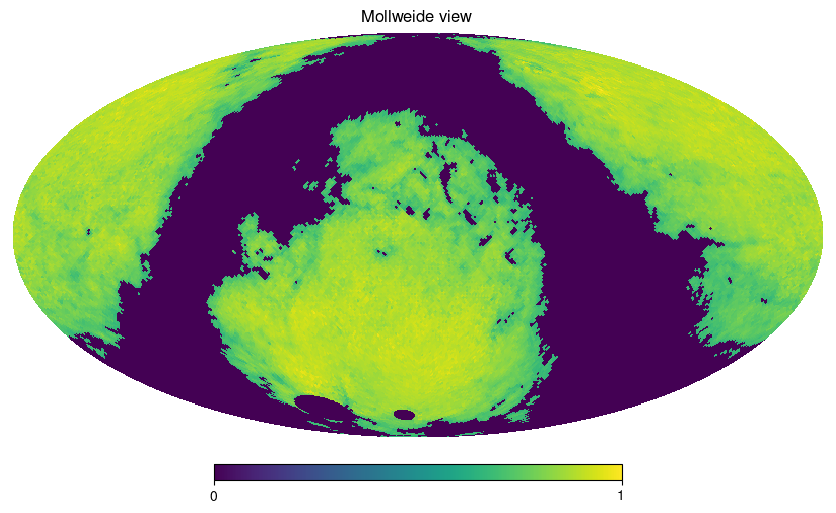

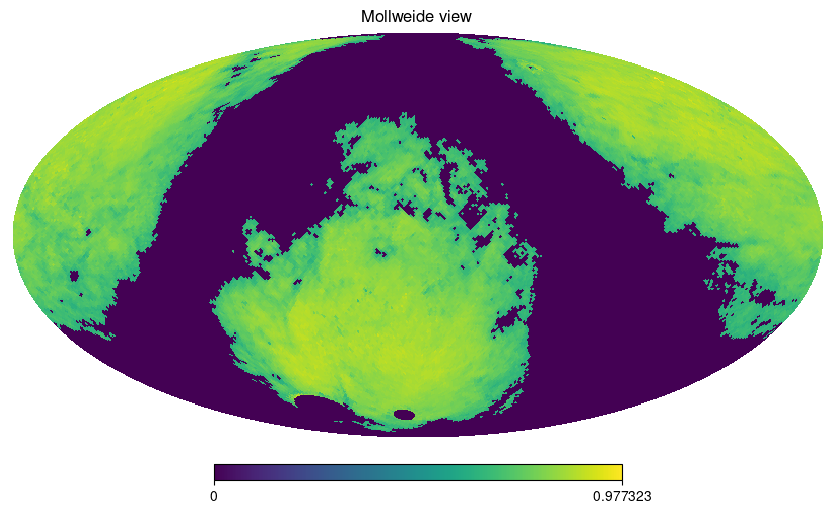

In [3]:
# Read and bin catalog
cat = Table.read(f'{predir}quaia_G{Gmag}.fits')
cats = [cat[(cat[zname] < z_edges[i+1]) & (cat[zname] >= z_edges[i])]
        for i in range(nbins)]

# Read selection function
if nbins == 1:
    fnames = [f"{predir}selection_function_NSIDE64_G{Gmag}.fits"]
else:
    fnames = [f"{predir}selection_function_NSIDE64_G{Gmag}_zsplit{nbins}bin{i}.fits"
              for i in range(nbins)]
masks = []
for fname in fnames:
    sel = hp.ud_grade(hp.read_map(fname),
                      nside_out=nside)
    mask = sel*(sel > sel_threshold)
    # Remove LMC and SMC
    v = hp.ang2vec(80.8917, -69.75, lonlat=True)
    disc = hp.query_disc(nside, v, np.radians(7))
    mask[disc] = 0
    v = hp.ang2vec(13.2042, -72.8286, lonlat=True)
    disc = hp.query_disc(nside, v, np.radians(3))
    mask[disc] = 0
    mask /= np.amax(mask)
    masks.append(mask)
masks = np.array(masks)

for mask in masks:
    hp.mollview(mask)

Construct systematic maps

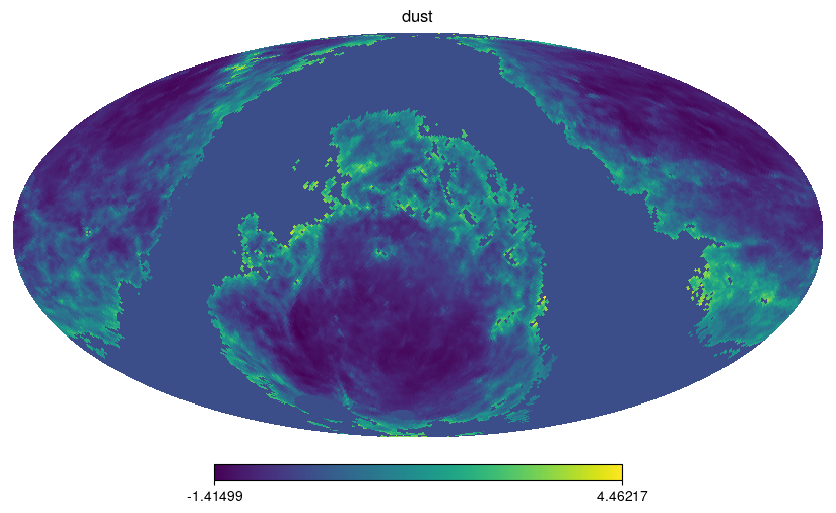

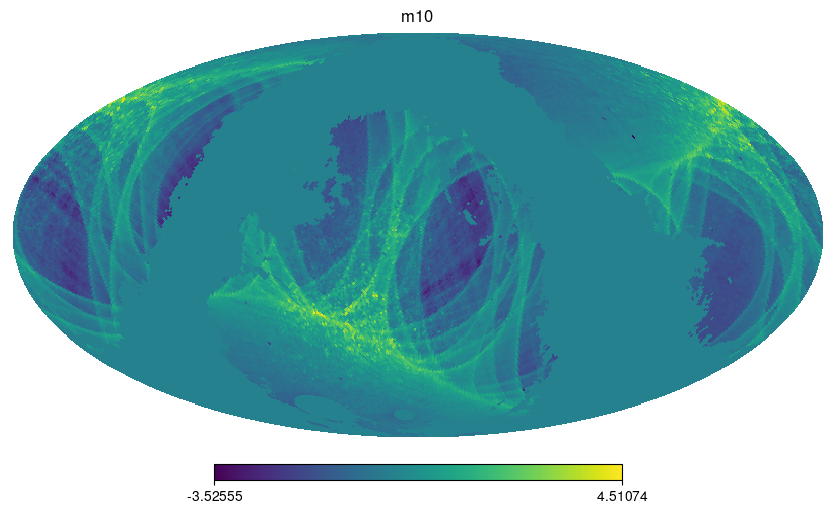

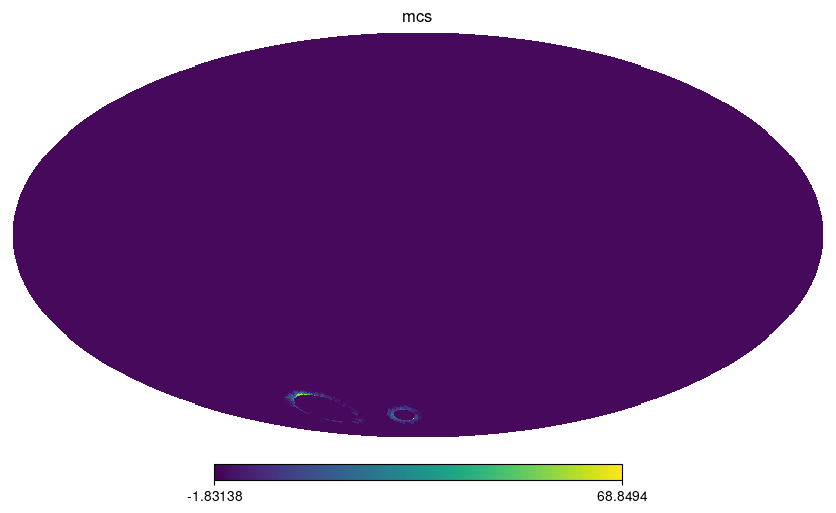

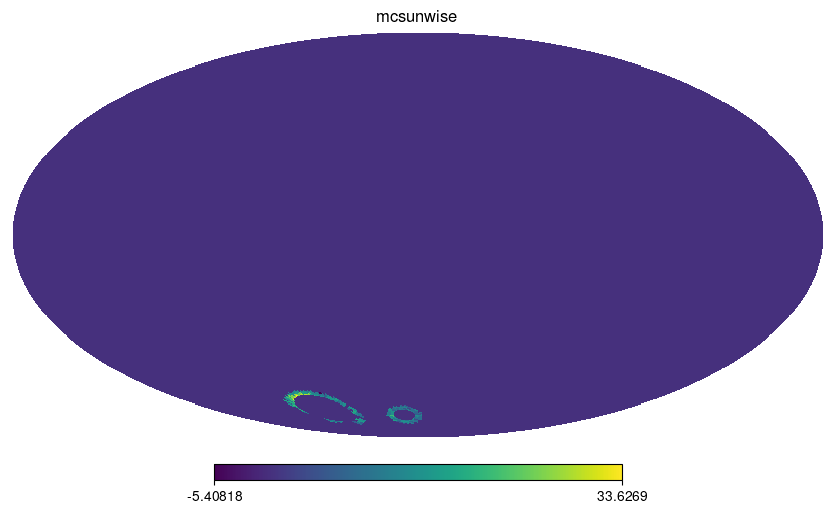

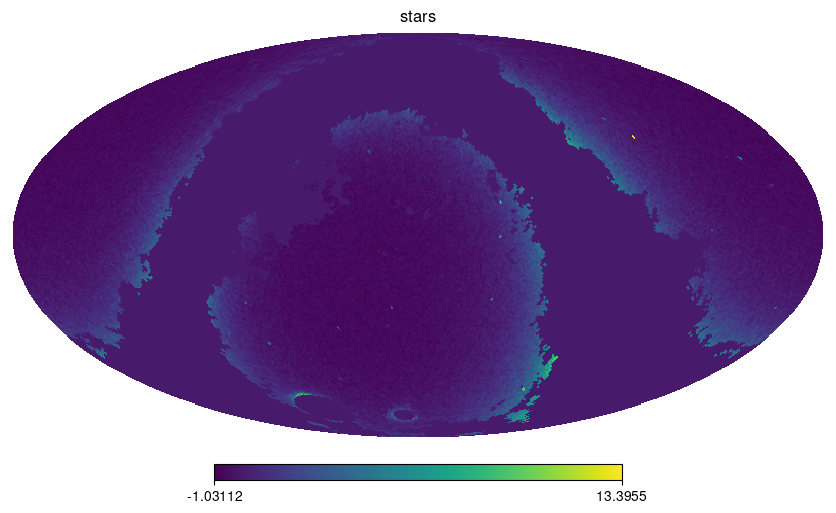

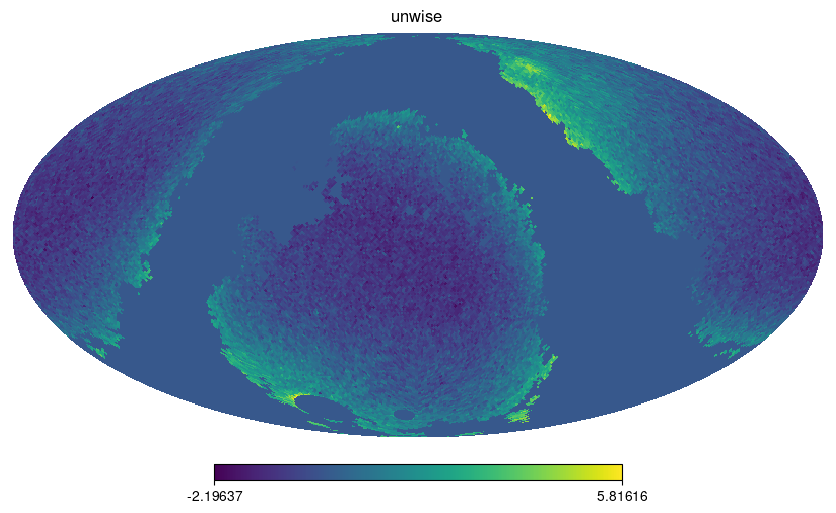

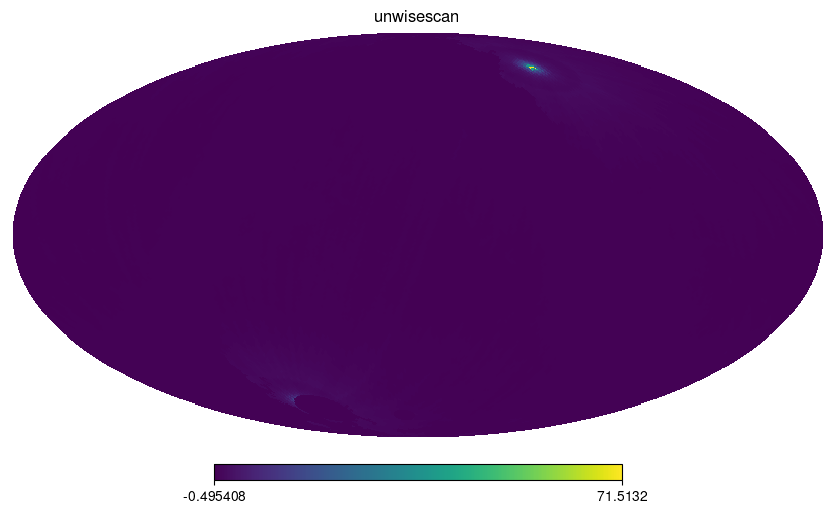

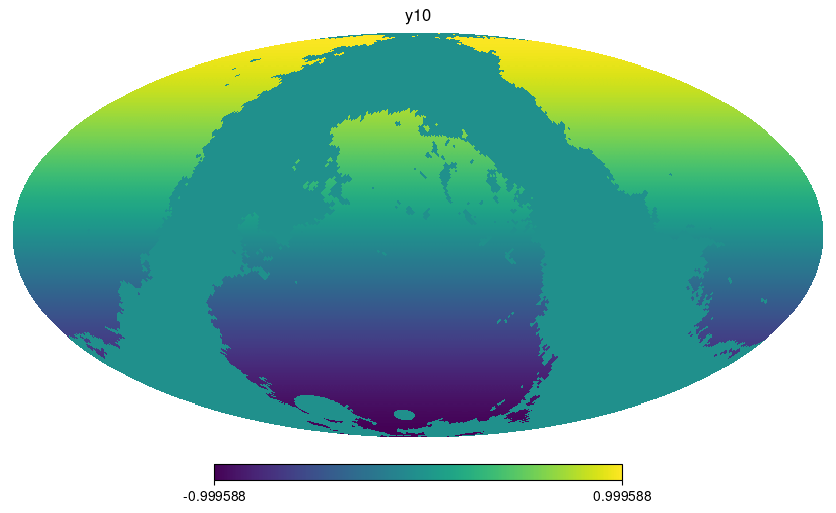

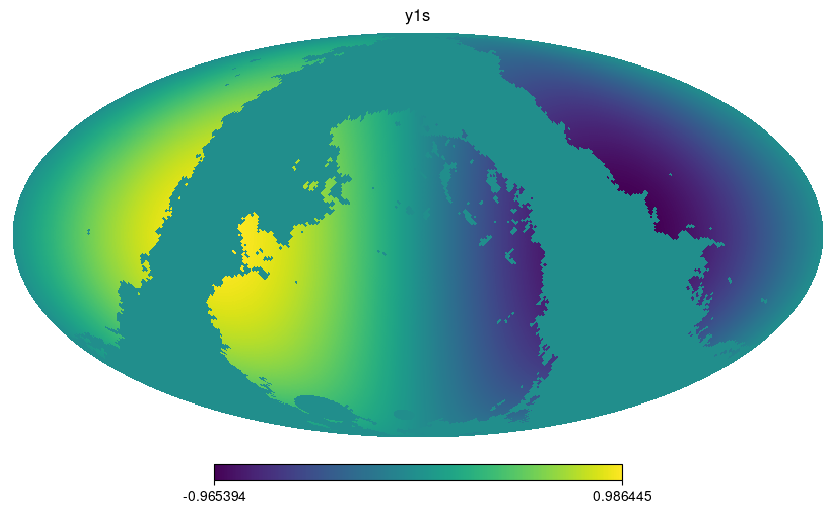

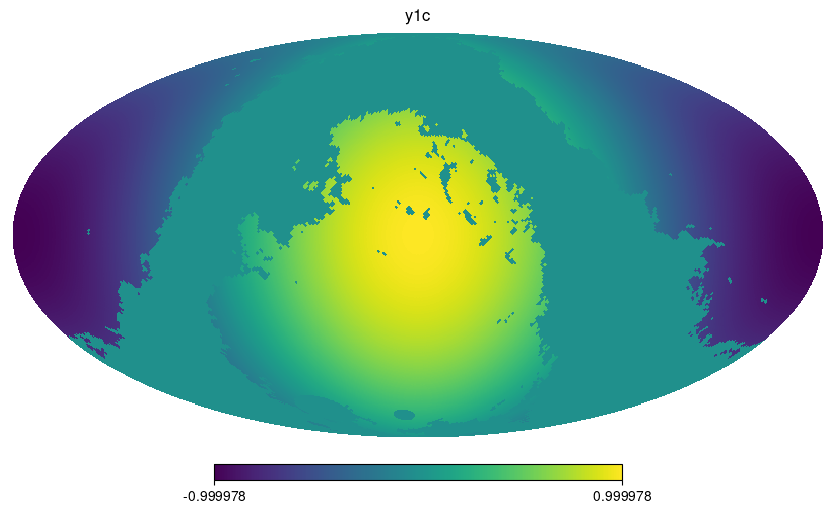

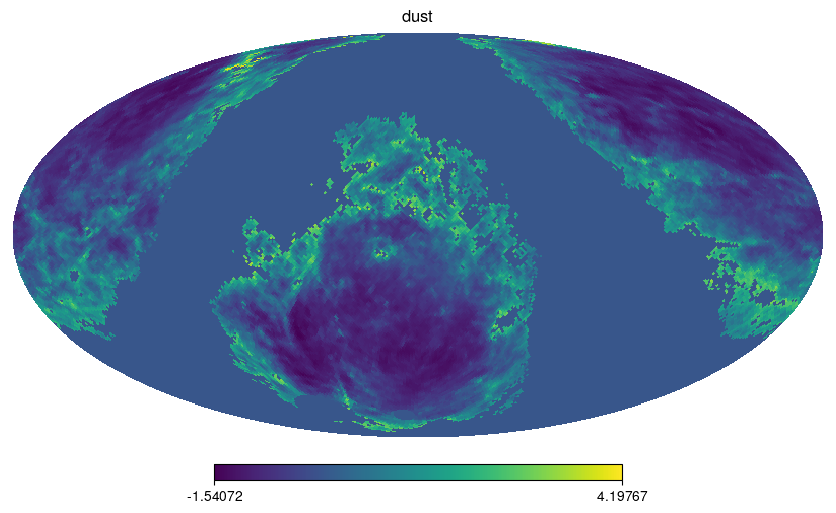

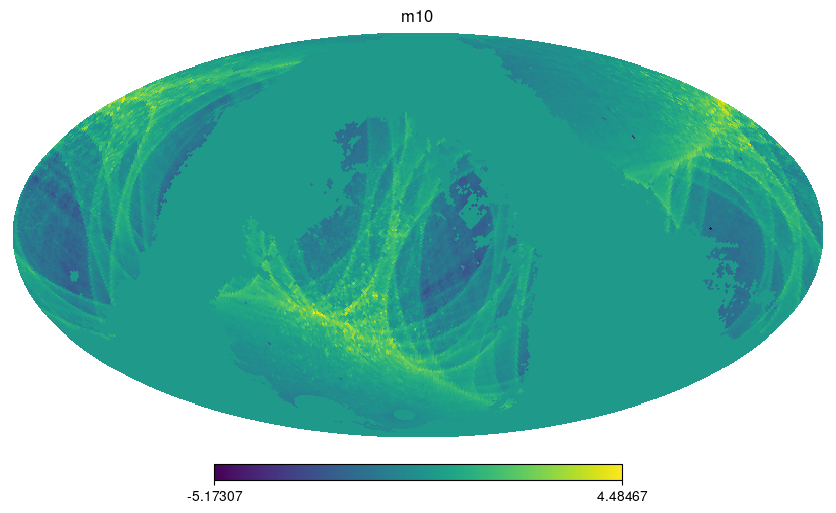

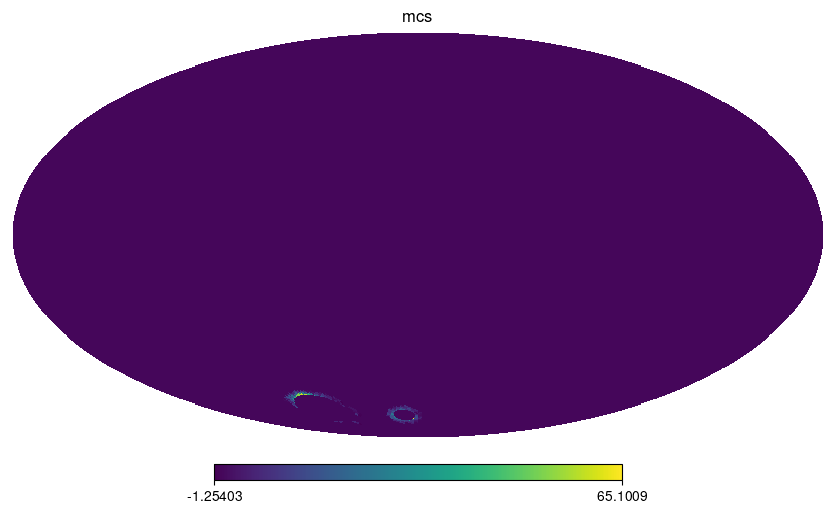

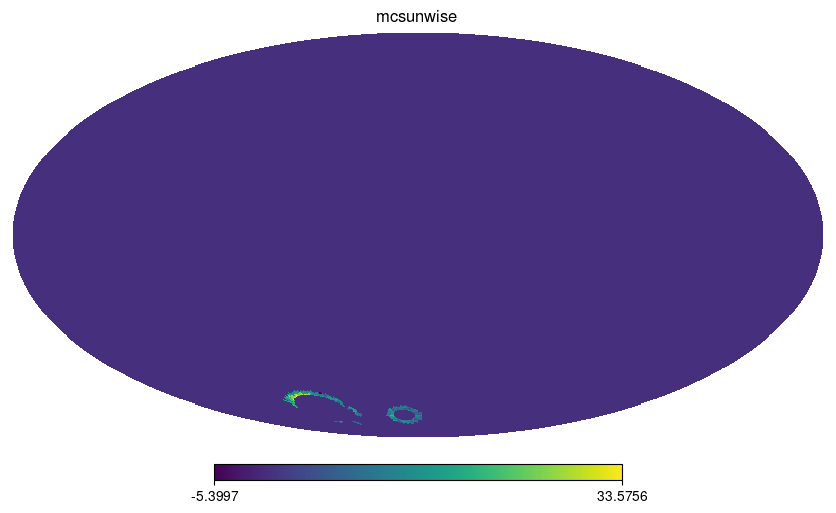

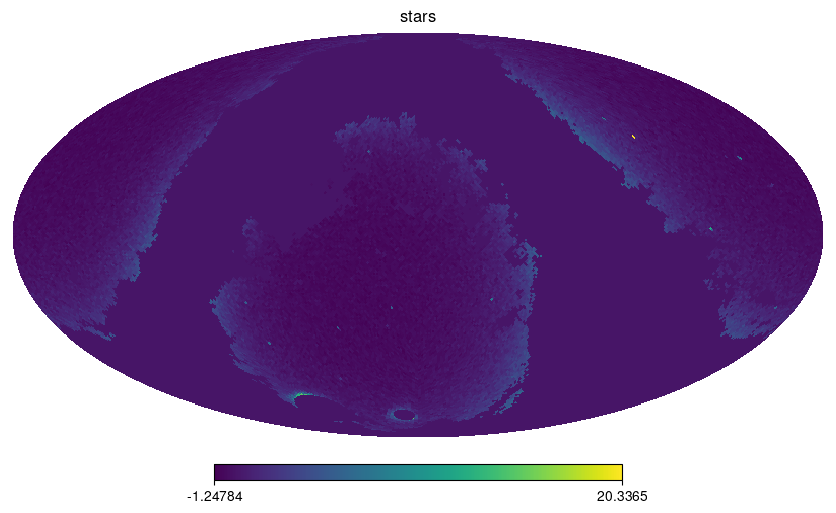

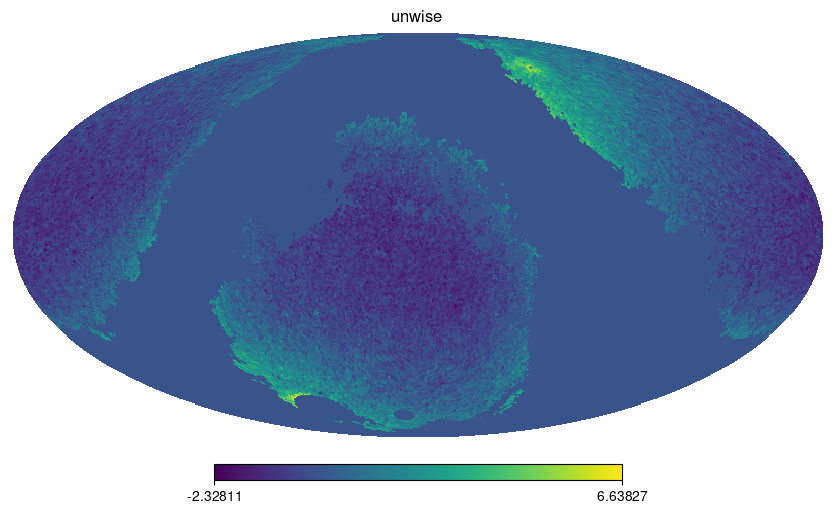

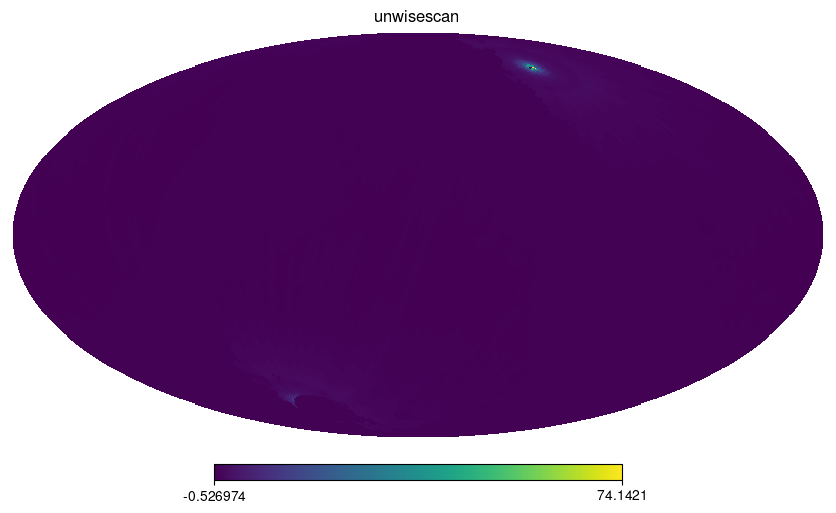

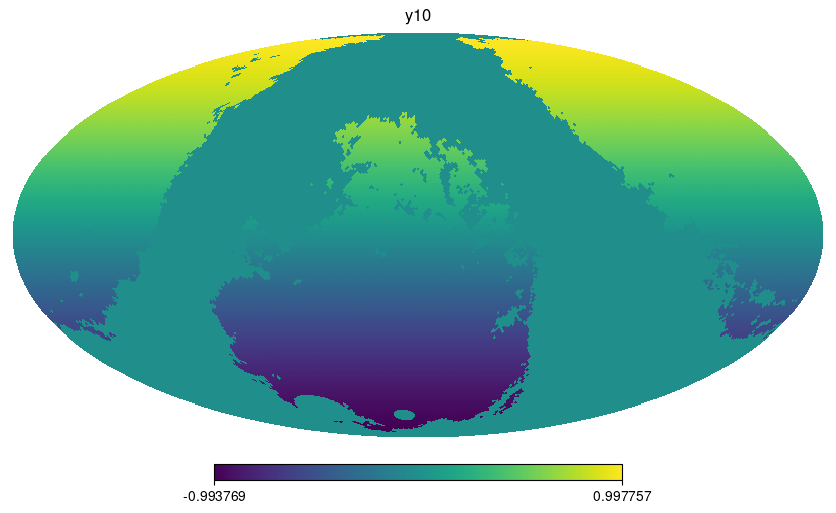

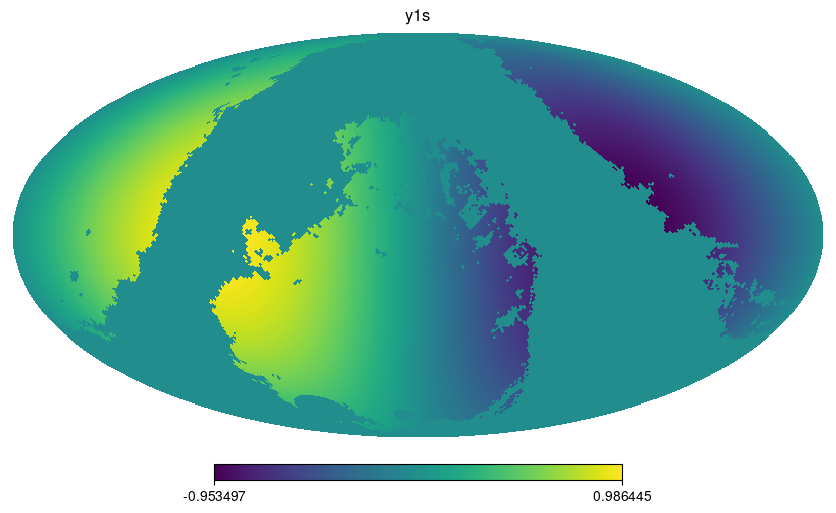

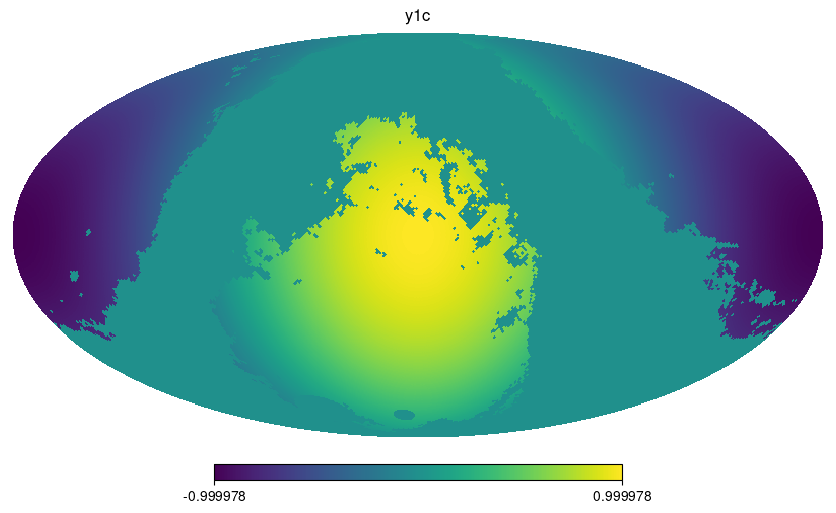

In [4]:
# Read systematic maps
sysnames = ['dust', 'm10', 'mcs', 'mcsunwise', 'stars', 'unwise', 'unwisescan']
syss = {f'gal{i}': {n: hp.ud_grade(np.load(f"{predir}map_{n}_NSIDE64.npy"), nside_out=nside) for n in sysnames} for i in range(nbins)}
th, phi = hp.pix2ang(nside, np.arange(npix))

for i in range(nbins):
    mask = masks[i]
    # Whiten maps
    for n in sysnames:
        m = syss[f'gal{i}'][n]
        mm = np.sum(m*mask)/np.sum(mask)
        msig = np.std((m - mm)[mask > 0])
        m = (m - mm)/msig * (mask > 0)
        syss[f'gal{i}'][n] = m
    
    # Add dipole to systematics
    syss[f'gal{i}']['y10'] = np.cos(th)*(mask > 0)
    syss[f'gal{i}']['y1s'] = np.sin(th)*np.sin(phi)*(mask > 0)
    syss[f'gal{i}']['y1c'] = np.sin(th)*np.cos(phi)*(mask > 0)

for i in range(nbins):
    sysnames = list(syss[f'gal{i}'].keys())
    for n in sysnames:
        hp.mollview(syss[f'gal{i}'][n], title=n)

Create galaxy overdensity fields and $N(z)$

In [5]:
def get_gal_field(cat, mask, sys):
    print(np.mean(cat[zname]),
          np.mean(cat[zname+'_err']),
          np.std(cat[zname+'_err']),
          np.mean(cat[zname+'_err']/(1+cat[zname])),
          np.std(cat[zname+'_err']/(1+cat[zname])))
    # Restrict catalog to binary mask
    mask_b = mask > 0
    ipix = hp.ang2pix(nside, cat['ra'], cat['dec'], lonlat=True)
    maskflag = mask_b[ipix]
    c = cat[maskflag]
    ipix = ipix[maskflag]

    # Construct redshift distribution
    zs = np.linspace(0., 4.5, num_z_bins)
    sz = c[zname+'_err']
    zm = c[zname]
    nz = np.array([np.sum(np.exp(-0.5*((z-zm)/sz)**2)/sz)
                   for z in zs])

    # Construct galaxy overdensity map
    nmap = np.bincount(ipix, minlength=npix)
    nmean = np.sum(nmap*mask_b)/np.sum(mask*mask_b)
    delta = np.zeros(npix)
    delta[mask_b] = nmap[mask_b]/(nmean*mask[mask_b])-1

    # Calculate noise pseudo-Cl
    nmean_srad = nmean * npix / (4*np.pi)
    pnl_gg = np.mean(mask) / nmean_srad * np.ones((1, 3*nside))
    
    # NaMaster fields (with and without deprojection)
    fg = nmt.NmtField(mask, [delta], n_iter=0)
    fg_dp = nmt.NmtField(mask, [delta], templates=[[sys[n]] for n in sysnames], n_iter=0)
    return {'map': delta, 'mask': mask, 'dndz': (zs, nz), 'pnl': pnl_gg, 'field': fg, 'field_dp': fg_dp, 'nmean': nmean}

fields = {}

for i in range(nbins):
    print(i)
    name = f'gal{i}'
    mdict = get_gal_field(cats[i], masks[i], syss[f'gal{i}'])
    fields[name] = mdict

0
0.9616881518490854 0.14315297201985772 0.1344044279053456 0.07239737884265025 0.06407673087415836
1
2.103120089111326 0.1902979313986904 0.18651849776523202 0.062237288974578295 0.061310721124870515


CMB lensing map

Reading data/kappa_ns256_rotated.fits
Reading data/mask_kappa_ns256_rotated.fits


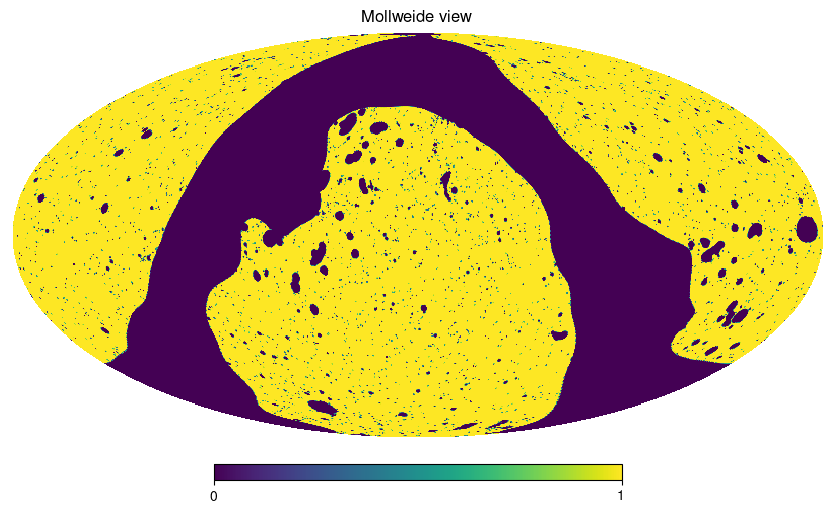

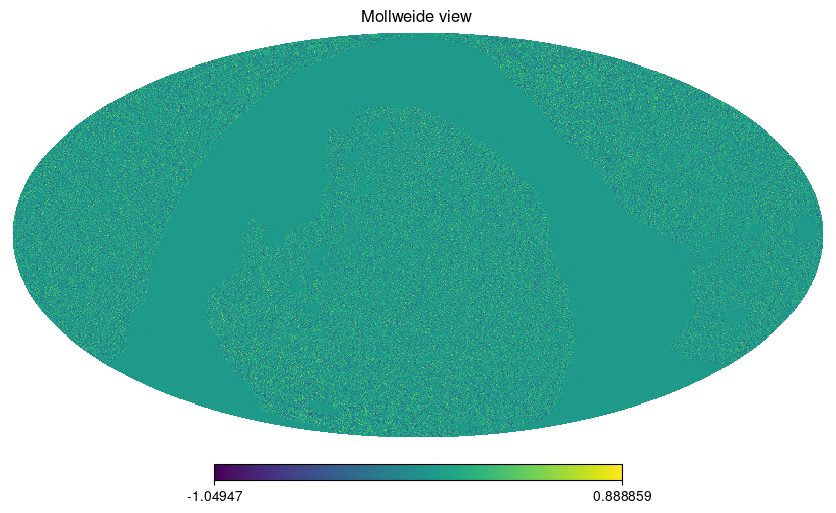

In [8]:
# Kappa map
fname = f"data/kappa_ns{nside}_rotated.fits"
if os.path.isfile(fname):
    print(f"Reading {fname}")
    kappa = hp.read_map(fname)
else:
    fname_kappa_planck = # Path to Planck kappa map
    klm, lmax = hp.read_alm(fname_kappa_planck,
                            return_mmax=True)
    # Fix ell=0
    klm[0] = 0+0j
    # Rotate alms
    rot = hp.Rotator(coord=['G', 'C'])
    klm = rot.rotate_alm(klm)
    # Truncate alms
    fl = np.ones(lmax+1)
    fl[3*nside:] = 0
    klm = hp.almxfl(klm, fl, inplace=True)
    # Transform to map
    kappa = hp.alm2map(klm, nside)
    hp.write_map(fname, kappa)

# Mask
fname = f"data/mask_kappa_ns{nside}_rotated.fits"
if os.path.isfile(fname):
    print(f"Reading {fname}")
    msk_k = hp.read_map(fname)
else:
    fname_mask_planck =  # Path to Planck kappa mask
    msk_k = hp.read_map(fname_mask_planck)
    # Rotate
    rot = hp.Rotator(coord=['G', 'C'])
    msk_k = rot.rotate_map_pixel(msk_k)
    # Apodize
    msk_k = nmt.mask_apodization(msk_k, 0.2, 'C1')
    # Binarize and downgrade
    msk_k[msk_k > 0.5] = 1
    msk_k[msk_k <= 0.5] = 0
    msk_k = hp.ud_grade(msk_k, nside_out=nside)
    # Save
    hp.write_map(fname, msk_k)

hp.mollview(msk_k)
hp.mollview(kappa)

# Field
fk = nmt.NmtField(msk_k, [kappa], n_iter=0)

fields['kappa'] = {'map': kappa, 'mask': msk_k, 'dndz': None,
                   'pnl': np.zeros((1, 3*nside)),
                   'field': fk, 'field_dp': fk}

Prepare everything to calculate power spectra

In [9]:
field_names = []
for i in range(nbins):
    field_names.append(f'gal{i}')
field_names.append('kappa')
nfields = len(field_names)

def get_cl_name(n1, n2, is_dp=False):
    if is_dp:
        suffix = '_dp'
    else:
        suffix = ''
    return f'{n1}_{n2}{suffix}'


def iterate_fields_all():
    for i in range(nfields):
        for j in range(i, nfields):
            yield field_names[i], field_names[j]


def iterate_fields():
    for i in range(nbins):
        n1 = f'gal{i}'
        for j in range(i, nbins):
            n2 = f'gal{j}'
            yield n1, n2
        yield n1, 'kappa'


l_edges = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26,
                    28, 30, 32, 34, 36, 38, 40, 45, 50, 55, 60, 90, 120,
                    150, 180, 210, 240, 270, 300, 330, 360, 390, 420,
                    450, 480, 510, 540, 570, 600, 630, 660, 690, 720, 768,
                    800, 900, 1000, 1100, 1200, 1300, 1400, 1536])
l_edges = l_edges[l_edges <= 3*nside]
b = nmt.NmtBin.from_edges(l_edges[:-1], l_edges[1:])
leff = b.get_effective_ells()
wsps = {f'{n1}_{n2}': nmt.NmtWorkspace.from_fields(fields[n1]['field'], fields[n2]['field'], b)
        for n1, n2 in iterate_fields_all()}

Compute kappa transfer function

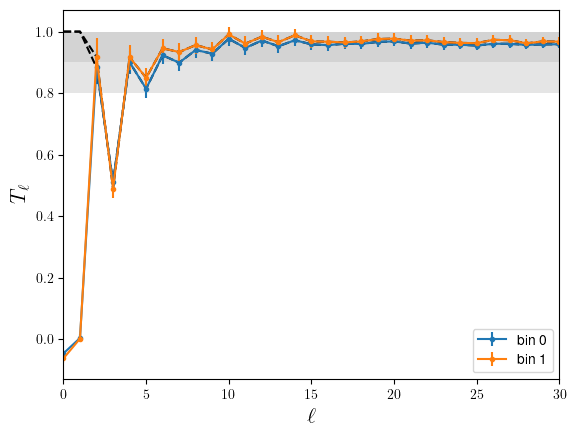

In [12]:
rot = hp.Rotator(coord=['C', 'G'])
masks_rotated = np.array([rot.rotate_map_pixel(m) for m in masks])

fname_mask_planck =  # Path to Planck kappa mask
mask_kappa = hp.ud_grade(hp.read_map(fname_mask_planck), nside_out=nside)

nsims_tot = 540

def process_ffp10_sim(seed):
    prefix =  # Path to directory where Planck input kappa simulations are stored
    fname_in = prefix+'ffp10_unlensed_scl_cmb_000_tebplm_mc_%04d.fits' % (seed+200)
    fname_out = f'{prefix}kappa_sim_in_ns{nside}'+'_%04d.fits' % seed
    if os.path.isfile(fname_out):
        kappa = hp.read_map(fname_out)
    else:
        lmax_out = 3*nside-1
        phi, lmax_in = hp.read_alm(fname_in, hdu=4, return_mmax=True)
        ll = np.arange(lmax_in+1)
        fl = ll*(ll+1)/2
        fl[lmax_out+1:] = 0
        phi = hp.almxfl(phi, fl, lmax_in)
        kappa = hp.alm2map(phi, nside)
        hp.write_map(fname_out, kappa)
    return kappa

def process_pr4_sim(seed):
    prefix =  # Path to directory where Planck reconstructed kappa simulations are stored
    fname_in = prefix+'klm_sim_%04d_p.fits' % seed
    fname_out = f'{prefix}kappa_sim_out_ns{nside}'+'_%04d.fits' % seed
    if os.path.isfile(fname_out):
        kappa = hp.read_map(fname_out)
    else:
        lmax_out = 3*nside-1
        kappa, lmax_in = hp.read_alm(fname_in, hdu=1, return_mmax=True)
        kappa[0] = 0+0j
        fl = np.ones(lmax_in+1)
        fl[lmax_out+1:] = 0
        kappa = hp.almxfl(kappa, fl, lmax_in)
        kappa = hp.alm2map(kappa, nside)
        hp.write_map(fname_out, kappa)
    return kappa

def get_cl_transfer_sims(imask):
    fname_out = f'data/cl_transfer_sims_ns{nside}_{nbins}bins_gal{imask}.npz'
    if os.path.isfile(fname_out):
        return np.load(fname_out)

    cls_uf = []
    cls_uu = []
    for i in range(nsims_tot):
        try:
            mp_in = process_ffp10_sim(i+60)
            mp_out = process_pr4_sim(i+60)
        except:
            print(f"simulation {i+60} not found")
            continue
        print(f"Analysing {i}-th sim")
        f_in_g = nmt.NmtField(masks_rotated[imask], [mp_in], n_iter=0)
        f_in_k = nmt.NmtField(mask_kappa, [mp_in], n_iter=3)
        f_out_k = nmt.NmtField(mask_kappa, [mp_out], n_iter=3)
        cl_uf = nmt.compute_coupled_cell(f_in_g, f_out_k)[0]
        cl_uu = nmt.compute_coupled_cell(f_in_g, f_in_k)[0]
        cls_uf.append(cl_uf)
        cls_uu.append(cl_uu)
    cls_uf = np.array(cls_uf)
    cls_uu = np.array(cls_uu)
    np.savez(fname_out, cls_uf=cls_uf, cls_uu=cls_uu, leff=leff)
    return {'cls_uf': cls_uf, 'cls_uu': cls_uu, 'leff': leff}

def interp_tf(tf):
    return interp1d(ls[ls>=2], tf[ls>=2], bounds_error=False, fill_value=1.0)

def get_transfer(imask):
    fname_out = f'data/tf_kappa_ns{nside}_{nbins}bins_gal{imask}.npz'
    if os.path.isfile(fname_out):
        d = np.load(fname_out)
        return interp_tf(d['transfer'])
    d = get_cl_transfer_sims(imask)
    cls_uf = d['cls_uf']
    cls_uu = d['cls_uu']
    nsims = len(cls_uf)
    print(f"{nsims} simulations read")
    clm_uf = np.mean(cls_uf, axis=0)
    cle_uf = np.std(cls_uf, axis=0)/np.sqrt(nsims)
    clm_uu = np.mean(cls_uu, axis=0)
    cle_uu = np.std(cls_uu, axis=0)/np.sqrt(nsims)
    transfer = clm_uf/clm_uu
    etransfer = np.sqrt(cle_uf**2/clm_uu**2+(clm_uf/clm_uu)**2*(cle_uu/clm_uu)**2)
    np.savez(fname_out, transfer=transfer, etransfer=etransfer)
    return interp_tf(transfer)

transfers = {f'gal{i}': get_transfer(i) for i in range(nbins)}

for i in range(nbins):
    d = np.load(f'data/tf_kappa_ns{nside}_{nbins}bins_gal{i}.npz')
    plt.errorbar(ls, d['transfer'], yerr=d['etransfer'], fmt='.-', label=f'bin {i}')
    plt.plot(ls, transfers[f'gal{i}'](ls), 'k--')
plt.axhspan(0.8, 1.0, facecolor='#AAAAAA', alpha=0.3)
plt.axhspan(0.9, 1.0, facecolor='#AAAAAA', alpha=0.3)
plt.xlim([0, 30])
plt.legend()
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$T_\ell$', fontsize=16);

Calculate TF due to deprojection

In [13]:
cl_tf = 1/(ls+30)

def get_dp_tf(n1, n2, nsims=100):
    fname = f'data/tf_dp_new_ns{nside}_{nbins}bins_{n1}_{n2}.npz'
    if os.path.isfile(fname):
        d = np.load(fname)
        return d

    print(n1, n2)
    # Precompute things
    w = wsps[f'{n1}_{n2}']
    mask1 = fields[n1]['mask']
    mask2 = fields[n2]['mask']

    # Compute power spectra
    clfs = []
    clus = []
    for i in range(nsims):
        if i % 10 == 0:
            print(i, nsims)
        m = hp.synfast(cl_tf, nside)
        f1 = nmt.NmtField(mask1, [m], n_iter=0)
        f2 = nmt.NmtField(mask2, [m], n_iter=0)
        if 'gal' in n1:
            temps = [[syss[n1][n]] for n in sysnames]
            f1dp = nmt.NmtField(mask1, [m], templates=temps, n_iter=0)
        else:
            f1dp = f1
        if 'gal' in n2:
            temps = [[syss[n2][n]] for n in sysnames]
            f2dp = nmt.NmtField(mask2, [m], templates=temps, n_iter=0)
        else:
            f2dp = f2
        clf = w.decouple_cell(nmt.compute_coupled_cell(f1dp, f2dp))[0]
        clu = w.decouple_cell(nmt.compute_coupled_cell(f1, f2))[0]
        clfs.append(clf)
        clus.append(clu)
    clfs = np.array(clfs)
    clus = np.array(clus)
    clf = np.mean(clfs, axis=0)

    # Compute TF and error
    elf = np.std(clfs, axis=0)/np.sqrt(100)
    clu = np.mean(clus, axis=0)
    elu = np.std(clus, axis=0)/np.sqrt(100)
    tfm = clf/clu
    tfe = tfm * np.sqrt((elf/clf)**2+(elu/clu)**2)
    data = {'clfs': clfs, 'clus': clus, 'transfer': tfm, 'transfer_error': tfe}
    np.savez(fname, **data)
    return data

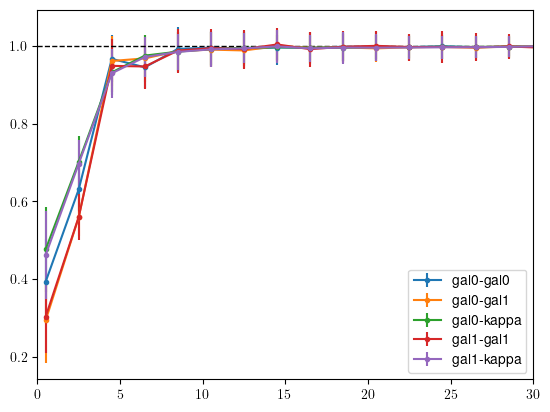

In [14]:
transfer_dp = {}
for n1, n2 in iterate_fields():
    d = get_dp_tf(n1, n2)
    transfer_dp[f'{n1}_{n2}'] = {'transfer': d['transfer'],
                                 'transfer_error': d['transfer_error']}

plt.figure()
for n1, n2 in iterate_fields():
    d = transfer_dp[f'{n1}_{n2}']
    plt.errorbar(leff, d['transfer'], yerr=d['transfer_error'], fmt='.-', label=f'{n1}-{n2}')
plt.axhline(1, ls='--', lw=1, color='k')
plt.xlim([0, 30])
plt.legend()

Calculate power spectra from data

In [15]:
def compute_cls(n1, n2, is_dp=False, flds=None):
    cut_short = True
    if flds is None:
        flds = fields
        cut_short = False

    if is_dp:
        suffix = '_dp'
    else:
        suffix = ''

    f1 = flds[n1][f'field{suffix}']
    f2 = flds[n2][f'field{suffix}']
    msk1 = flds[n1]['mask']
    msk2 = flds[n2]['mask']
    fsky = np.mean(msk1*msk2)
    cl_name = get_cl_name(n1, n2, is_dp=is_dp)

    # Get workspace
    w = wsps[f'{n1}_{n2}']

    # Pseudo-Cl
    pcl = nmt.compute_coupled_cell(f1, f2)

    # Kappa transfer function
    tf_kappa_corr = 1
    if include_TF_kappa and (n1 != n2):  # It's g-kappa
        gname = n2 if n1 == 'kappa' else n1
        tf_kappa_corr = 1/transfers[gname](leff)
    
    # Deprojection bias
    tf_dp_corr = 1
    if is_dp and include_TF_dp and not ((n1 == 'kappa') and (n2 == 'kappa')):
        tf_dp = transfer_dp[f'{n1}_{n2}']['transfer']
        tf_dp_corr = 1/tf_dp

    if cut_short:
        cl = tf_kappa_corr * tf_dp_corr * w.decouple_cell(pcl)[0]
        return {'cl': cl}

    # Noise bias
    if n1 == n2:
        pnl = fields[n1]['pnl']
        nl = w.decouple_cell(pnl)[0]
    else:
        nl = 0

    # "Theory" prediction
    clth = pcl[0]/fsky

    # Cl
    cl = tf_kappa_corr * tf_dp_corr * (w.decouple_cell(pcl)[0]-nl)

    return {'cl': cl, 'clth': clth, 'pcl': pcl, 'nl': nl, 'w': w}

cls_data = {}

for is_dp in [False, True]:
    for n1, n2 in iterate_fields_all():
        cl_name = get_cl_name(n1, n2, is_dp)
        print(n1, n2, cl_name)
        cls_data[cl_name] = compute_cls(n1, n2, is_dp)

gal0 gal0 gal0_gal0
gal0 gal1 gal0_gal1
gal0 kappa gal0_kappa
gal1 gal1 gal1_gal1
gal1 kappa gal1_kappa
kappa kappa kappa_kappa
gal0 gal0 gal0_gal0_dp
gal0 gal1 gal0_gal1_dp
gal0 kappa gal0_kappa_dp
gal1 gal1 gal1_gal1_dp
gal1 kappa gal1_kappa_dp
kappa kappa kappa_kappa_dp


Calculate covariance from Gaussian sims

In [16]:
# Build Cl matrix
def get_clth(n1, n2):
    clname = get_cl_name(n1, n2, is_dp=True)
    if not (clname in cls_data):  # If not in list of computed C_ells, flip order
        clname = get_cl_name(n2, n1, is_dp=True)
    cl = cls_data[clname]['clth']
    return cl


clthmat = np.zeros([nfields, nfields, 3*nside])
for i1, n1 in enumerate(field_names):
    for i2, n2 in enumerate(field_names):
        cl = get_clth(n1, n2)
        clthmat[i1, i2, :] = cl

# Sort in HEAPix order
cltharr = []
for idiag in range(nfields):
    for ifield in range(nfields):
        i1 = ifield
        i2 = ifield+idiag
        if i2 >= nfields:
            continue
        cltharr.append(clthmat[i1, i2])
cltharr = np.array(cltharr)

In [17]:
def gen_gaussian_sim():
    alms = hp.synalm(cltharr, lmax=3*nside-1, mmax=3*nside-1, new=True)
    mps = np.array([hp.alm2map(alm, nside) for alm in alms])
    return mps

In [18]:
nsims = 1000

fname = f'data/cls_sims_{nbins}bins_ns{nside}_kappaTF{include_TF_kappa}_dpTF{include_TF_dp}.npz'

if os.path.isfile(fname):
    d = np.load(fname)
    cls_sims = d['cls_sims']
    cls_sims_dp = d['cls_sims_dp']
else:
    
    cls_sims = []
    cls_sims_dp = []
    
    for i in range(nsims):
        #if i % 100 == 0:
        print(i)
        mps = gen_gaussian_sim()
    
        # Non-deprojected fields
        flds = {}
        for mp, nm in zip(mps, field_names):
            msk = fields[nm]['mask']
            f = nmt.NmtField(msk, [mp], n_iter=0)
            flds[nm] = {'mask': mask, 'field': f, 'field_dp': f}
        cls = []
        for n1, n2 in iterate_fields():
            cl = compute_cls(n1, n2, flds=flds)['cl']
            cls.append(cl)
        cls_sims.append(np.concatenate(cls))
    
        # Deprojected fields
        flds = {}
        for mp, nm in zip(mps, field_names):
            msk = fields[nm]['mask']
            if 'gal' in nm:
                f = nmt.NmtField(msk, [mp], n_iter=0,
                                 templates=[[syss[nm][n]] for n in sysnames])
            else:
                f = nmt.NmtField(msk, [mp], n_iter=0)
            flds[nm] = {'mask': mask, 'field': f, 'field_dp': f}
        cls = []
        for n1, n2 in iterate_fields():
            cl = compute_cls(n1, n2, flds=flds)
            cl = cl['cl']
            cls.append(cl)
        cls_sims_dp.append(np.concatenate(cls))
    
    cls_sims = np.array(cls_sims)
    cls_sims_dp = np.array(cls_sims_dp)
    np.savez(fname, cls_sims=cls_sims, cls_sims_dp=cls_sims_dp, field_names=field_names)

cov_sims = np.cov(cls_sims.T)
cov_sims_dp = np.cov(cls_sims_dp.T)
cov_sims_diff = np.cov((cls_sims_dp - cls_sims).T)

Calculate analytical covariance

In [19]:
ncls = 0
for _, _ in iterate_fields():
    ncls += 1
nbpw = len(leff)

cov_ana = np.zeros([ncls, ncls, nbpw, nbpw])


for icla, (na1, na2) in enumerate(iterate_fields()):
    wa = wsps[f'{na1}_{na2}']
    for iclb, (nb1, nb2) in enumerate(iterate_fields()):
        print(icla, na1, na2, iclb, nb1, nb2)
        wb = wsps[f'{nb1}_{nb2}']
        cw = nmt.NmtCovarianceWorkspace.from_fields(fields[na1]['field'], fields[na2]['field'],
                                                    fields[nb1]['field'], fields[nb2]['field'])
        cla1b1 = get_clth(na1, nb1)
        cla1b2 = get_clth(na1, nb2)
        cla2b1 = get_clth(na2, nb1)
        cla2b2 = get_clth(na2, nb2)
        cov = nmt.gaussian_covariance(cw, 0, 0, 0, 0,
                                      [cla1b1], [cla1b2],
                                      [cla2b1], [cla2b2],
                                      wa, wb=wb)
        cov_ana[icla, iclb, :, :] = cov
cov_ana = np.transpose(cov_ana, axes=[0, 2, 1, 3]).reshape([ncls*nbpw, ncls*nbpw])

0 gal0 gal0 0 gal0 gal0
0 gal0 gal0 1 gal0 gal1
0 gal0 gal0 2 gal0 kappa
0 gal0 gal0 3 gal1 gal1
0 gal0 gal0 4 gal1 kappa
1 gal0 gal1 0 gal0 gal0
1 gal0 gal1 1 gal0 gal1
1 gal0 gal1 2 gal0 kappa
1 gal0 gal1 3 gal1 gal1
1 gal0 gal1 4 gal1 kappa
2 gal0 kappa 0 gal0 gal0
2 gal0 kappa 1 gal0 gal1
2 gal0 kappa 2 gal0 kappa
2 gal0 kappa 3 gal1 gal1
2 gal0 kappa 4 gal1 kappa
3 gal1 gal1 0 gal0 gal0
3 gal1 gal1 1 gal0 gal1
3 gal1 gal1 2 gal0 kappa
3 gal1 gal1 3 gal1 gal1
3 gal1 gal1 4 gal1 kappa
4 gal1 kappa 0 gal0 gal0
4 gal1 kappa 1 gal0 gal1
4 gal1 kappa 2 gal0 kappa
4 gal1 kappa 3 gal1 gal1
4 gal1 kappa 4 gal1 kappa


Compare both covariances

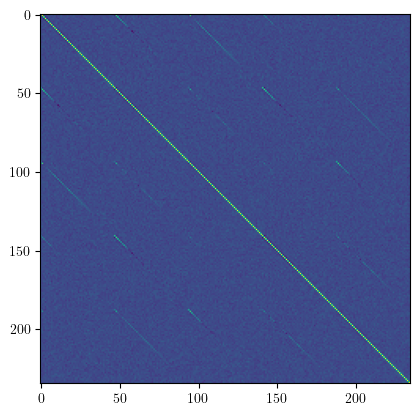

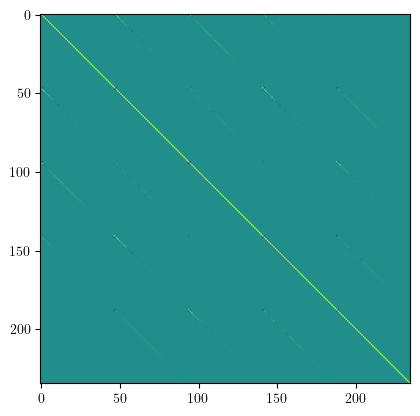

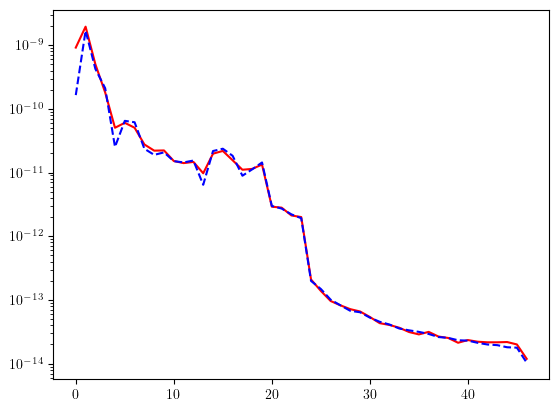

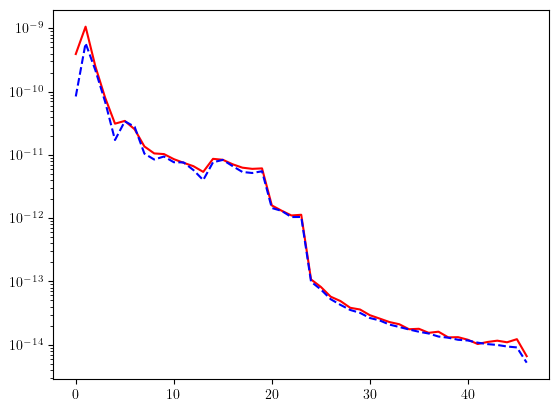

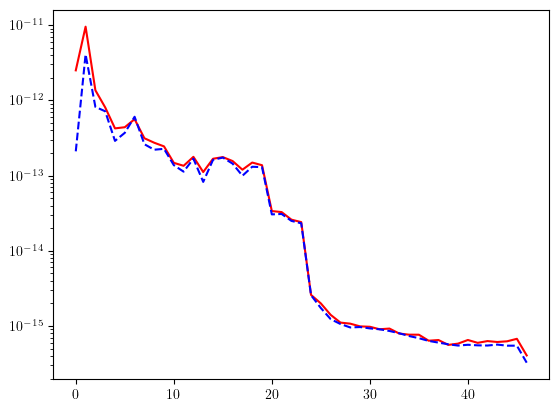

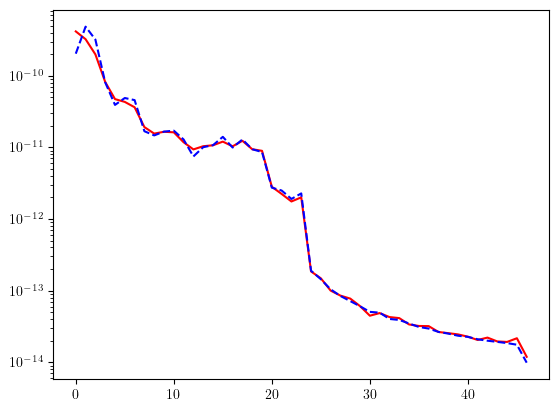

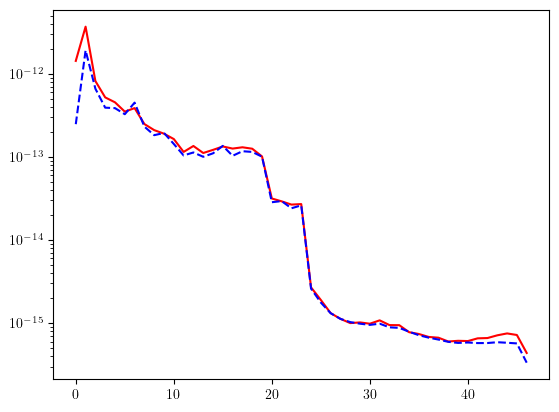

In [20]:
plt.figure()
plt.imshow(cov_sims/np.sqrt(np.outer(np.diag(cov_sims), np.diag(cov_sims))))
plt.figure()
plt.imshow(cov_ana/np.sqrt(np.outer(np.diag(cov_ana), np.diag(cov_ana))))

for i in range(ncls):
    plt.figure()
    plt.plot(np.diag(cov_sims)[i*nbpw:(i+1)*nbpw], 'r-')
    plt.plot(np.diag(cov_ana)[i*nbpw:(i+1)*nbpw], 'b--')
    plt.yscale('log')

Save SACC file

In [20]:
def save_sacc_file(is_dp, cov, fname):
    s = sacc.Sacc()
    
    # Add one tracer per map
    for i in range(nbins):
        tname = f'gal{i}'
        z, nz = fields[tname]['dndz']
        s.add_tracer('NZ', tname, quantity='galaxy_density',
                     spin=0, z=z, nz=nz)
    s.add_tracer('Map', 'kappa', quantity='cmb_convergence', spin=0,
                 ell=ls, beam=np.ones(3*nside))

    for n1, n2 in iterate_fields():
        w = wsps[f'{n1}_{n2}']
        Bbl = w.get_bandpower_windows().squeeze().T
        clname = get_cl_name(n1, n2, is_dp=is_dp)
        cl = cls_data[clname]
        s.add_ell_cl('cl_00', n1, n2, leff, cl['cl'],
                     window=sacc.BandpowerWindow(ls, Bbl))
    
    # Add covariance
    s.add_covariance(cov)
    s.save_fits(fname, overwrite=True)


# C_ells with deprojection
save_sacc_file(True, cov_sims_dp,
               f"data/cls_quaia_planckPR4_{nbins}bins_ns{nside}_kappaTF{include_TF_kappa}_dpTF{include_TF_dp}_dp.fits")
# No deprojection
save_sacc_file(False, cov_sims,
               f"data/cls_quaia_planckPR4_{nbins}bins_ns{nside}_kappaTF{include_TF_kappa}_dpTF{include_TF_dp}.fits")
# Save extra info
dictsave = {}
for i in range(nbins):
    tname = f'gal{i}'
    clname = get_cl_name(tname, tname)
    nl = cls_data[clname]['nl']
    dictsave[f'nl_gal{i}'] = nl
dictsave['cl_names'] = [get_cl_name(n1, n2) for n1, n2 in iterate_fields()]
dictsave['cov_analytical'] = cov_ana
np.savez(f"data/cls_quaia_planckPR_{nbins}bins_ns{nside}_kappaTF{include_TF_kappa}_dpTF{include_TF_dp}_extra.npz",
         **dictsave)